<a href="https://colab.research.google.com/github/spoorthiggowda917-cpu/MediTrak-ML-Project/blob/main/Meditrack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ All libraries loaded successfully!
📂 Click 'Choose Files' and upload expiry_dirty.csv ...


Saving expiry_dirty.csv to expiry_dirty (4).csv

✓ Loaded: expiry_dirty (4).csv
   Rows: 10,000  |  Columns: 20

Columns:
['Medicine_ID', 'Medicine_Name', 'Batch_ID', 'Category', 'Purchase_Date', 'Expiry_Date', 'Stock_Quantity', 'Unit_Price', 'Total_Value', 'Daily_Sales', 'Weekly_Sales', 'Monthly_Sales', 'Sales_Velocity', 'Reorder_Level', 'Last_Restock_Date', 'Days_To_Expiry', 'Shelf_Life_Months', 'Supplier_ID', 'Storage_Condition', 'Risk_Level']

First 3 rows:


,Medicine_ID,Medicine_Name,Batch_ID,Category,Purchase_Date,Expiry_Date,Stock_Quantity,Unit_Price,Total_Value,Daily_Sales,Weekly_Sales,Monthly_Sales,Sales_Velocity,Reorder_Level,Last_Restock_Date,Days_To_Expiry,Shelf_Life_Months,Supplier_ID,Storage_Condition,Risk_Level
0,MED_6166,Medicine_914,BATCH_247,Sprays,2023-03-09,2024-04-10,2544.0,480.09,1256996.67,44.0,308,1320,20.04,52,2023-02-16,28,23,SUP_310,cool,1
1,MED_1903,Medicine_822,BATCH_597,Lotions,2023-11-28,2024-07-02,2046.0,292.57,782786.81,78.0,546,2340,16.93,53,2023-07-04,249,20,SUP_285,Cool Dry,0
2,MED_3732,Medicine_476,BATCH_892,Drops,2023-12-22,2024-03-19,2717.0,437.59,238652.14,48.0,336,1440,45.31,417,2023-09-01,56,22,SUP_323,Cool Dry,high risk


EXPLORATORY DATA ANALYSIS

📐 Shape: (10000, 20)

🔢 Data Types:
Medicine_ID           object
Medicine_Name         object
Batch_ID              object
Category              object
Purchase_Date         object
Expiry_Date           object
Stock_Quantity        object
Unit_Price            object
Total_Value          float64
Daily_Sales           object
Weekly_Sales           int64
Monthly_Sales          int64
Sales_Velocity        object
Reorder_Level          int64
Last_Restock_Date     object
Days_To_Expiry         int64
Shelf_Life_Months      int64
Supplier_ID           object
Storage_Condition     object
Risk_Level            object
dtype: object

⚠️  Missing Value Summary:
                   Missing      %
Storage_Condition     1398  13.98
Risk_Level            1026  10.26
Category               681   6.81
Unit_Price             354   3.54
Daily_Sales            351   3.51
Expiry_Date            340   3.40
Stock_Quantity         315   3.15
Sales_Velocity         279   2.79
Supplier_

,Total_Value,Weekly_Sales,Monthly_Sales,Reorder_Level,Days_To_Expiry,Shelf_Life_Months
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.459572e+05,351.064700,1504.563000,274.689200,184.842200,20.991700
std,5.556795e+05,202.568693,868.151541,129.777077,129.453743,8.962046
min,0.000000e+00,0.000000,0.000000,50.000000,-30.000000,6.000000
25%,1.831502e+05,175.000000,750.000000,162.000000,88.000000,13.000000
50%,4.833640e+05,357.000000,1530.000000,274.000000,182.000000,21.000000
75%,9.976077e+05,525.000000,2250.000000,386.000000,273.000000,29.000000
max,2.475233e+06,700.000000,3000.000000,500.000000,1500.000000,36.000000


DATA CLEANING

1. Fixing Stock_Quantity...
   Negative values fixed: 94  |  NaN filled with median: 2488

2. Fixing Unit_Price...
   Filled 354 NaN with median: 250.87

3. Fixing Daily_Sales & Sales_Velocity...
   Done.

4. Parsing dates...
   Rows dropped (missing Expiry_Date): 497

5. Normalising Category...
   Categories after cleaning: ['Capsules', 'Drops', 'Inhalers', 'Injections', 'Lotions', 'Ointments', 'Other', 'Powders', 'Sprays', 'Syrups', 'Tablets', 'Unknown']

6. Normalising Storage_Condition...
   Storage types: {'Room Temp': 4063, 'Refrigerated': 2787, 'Cool Dry': 2653}

7. Removing zero-stock rows...
   Removed: 1  |  Remaining: 9,502

✓ Cleaning complete!  Final shape: (9502, 20)
FEATURE ENGINEERING
Reference date: 2023-12-02
1. DaysToExpiry  →  range: 30 to 392
2. StockAgeInDays  →  mean: 156
3. DaysToStockOut  →  median: 49
4. TurnoverRatio  →  median: 7.23
5. IsSlowMoving  →  2,351 items (threshold < 26.0)
6. ExpiryVsStockoutRatio  →  median: 3.73
7. ValueAtRisk  →  

,DaysToExpiry,StockAgeInDays,DaysToStockOut,TurnoverRatio,IsSlowMoving,ValueAtRisk
count,9502.000000,9502.000000,9502.000000,9502.000000,9502.000000,9.502000e+03
mean,211.227110,156.289097,110.842378,26.718349,0.247422,7.545217e+05
std,104.629884,103.534099,272.477692,214.310599,0.431536,2.156461e+06
min,30.000000,0.000000,-9999.900000,0.000000,0.000000,9.663000e+01
25%,121.000000,66.000000,24.371528,3.654019,0.000000,1.868932e+05
50%,213.000000,157.000000,49.440442,7.230368,0.000000,4.906896e+05
75%,301.000000,249.000000,94.030749,14.373187,0.000000,9.582212e+05
max,392.000000,335.000000,999.000000,16560.000000,1.000000,4.826252e+07


EDA VISUALISATIONS


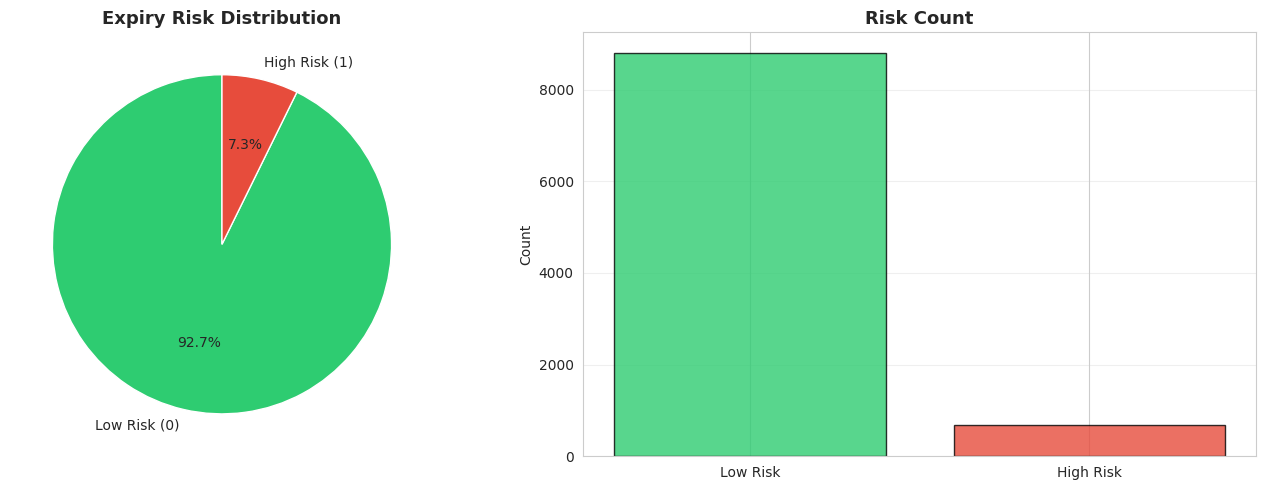

   Class 0: 8,810  |  Class 1: 692  |  High-risk %: 7.3%


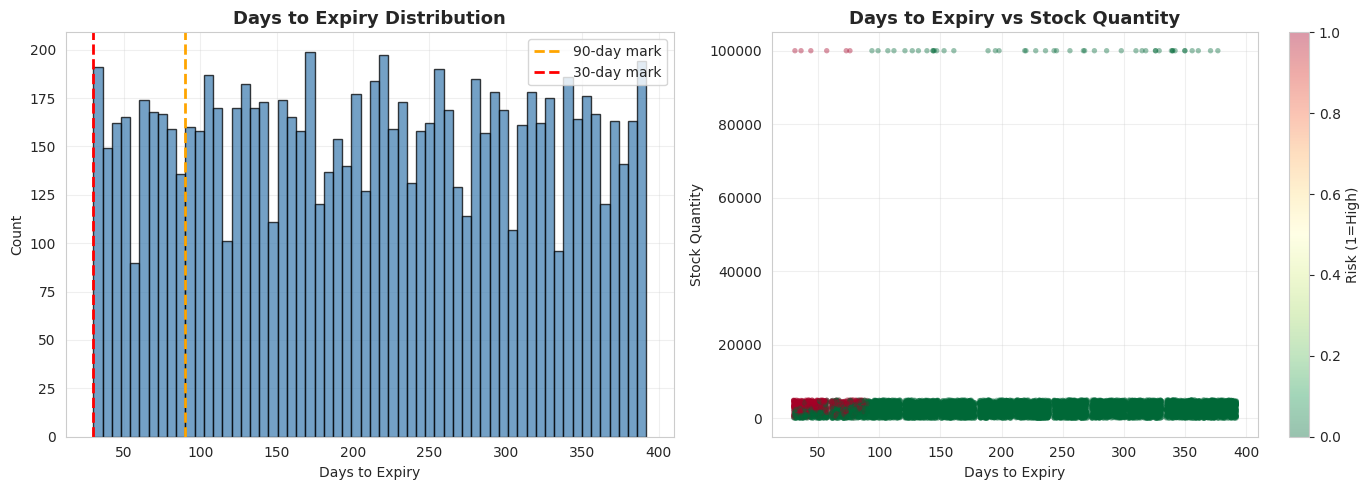

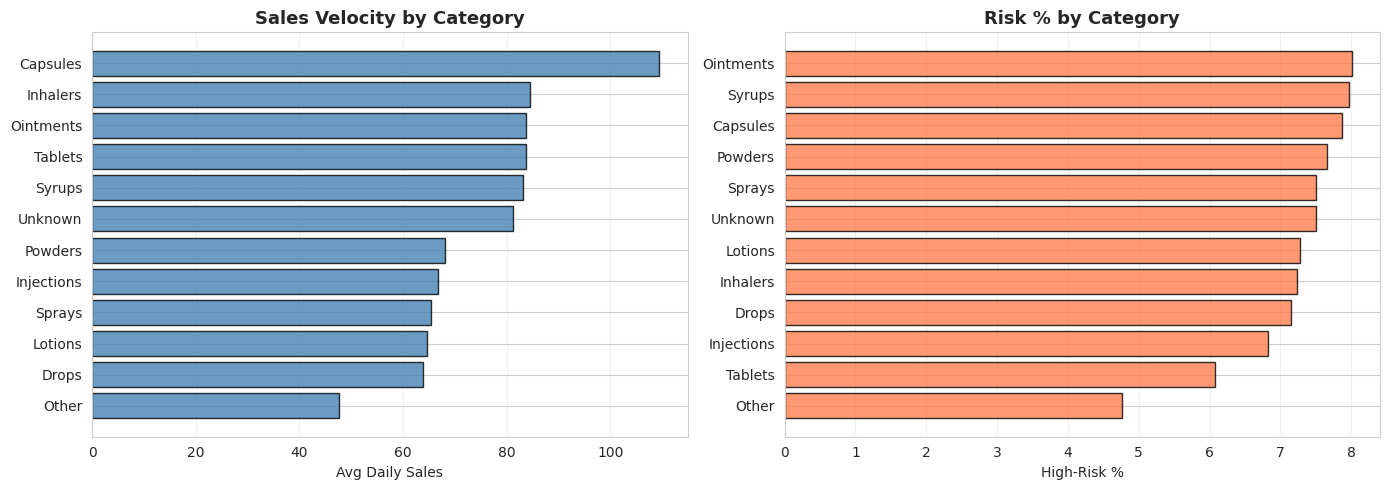

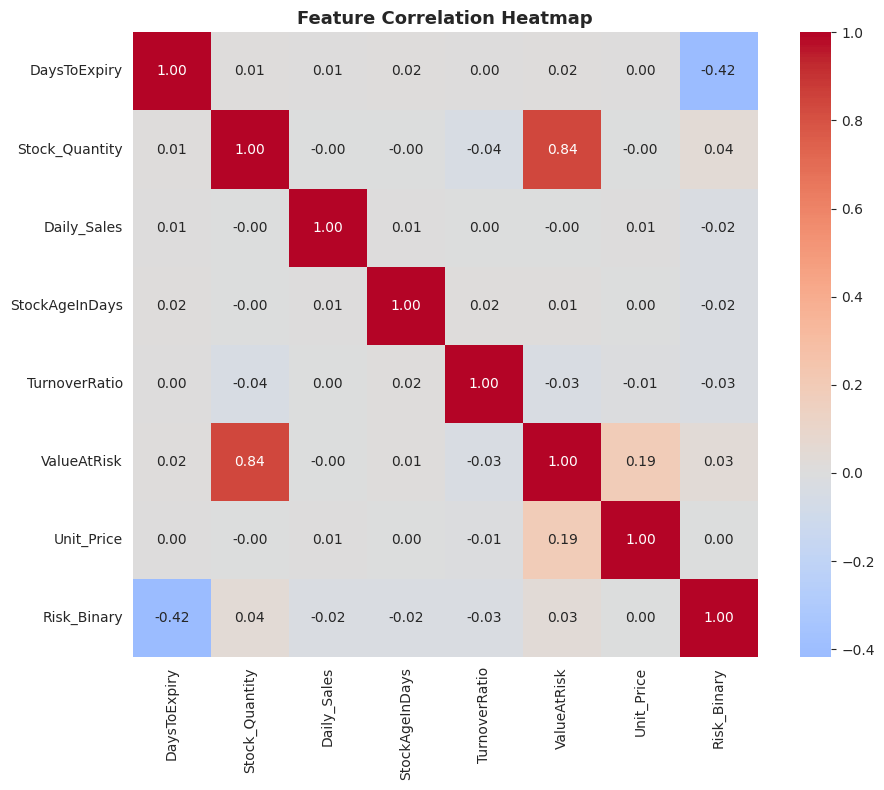


✓ EDA visualisations complete!
PREPARING DATA FOR MACHINE LEARNING
Features: 15  |  Samples: 9,502
Class 0: 8,810  |  Class 1: 692

Train: 7,601 rows  |  Test: 1,901 rows
Train high-risk %: 7.3%  |  Test high-risk %: 7.3%
MODEL 1: LOGISTIC REGRESSION (Baseline)
  Accuracy : 0.9669
  Precision: 0.8378
  Recall   : 0.6739
  F1-Score : 0.7470
  ROC-AUC  : 0.9909

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1763
           1       0.84      0.67      0.75       138

    accuracy                           0.97      1901
   macro avg       0.91      0.83      0.86      1901
weighted avg       0.96      0.97      0.97      1901

MODEL 2: RANDOM FOREST CLASSIFIER
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000
  F1-Score : 1.0000
  ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1763
           1       

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9669,0.8378,0.6739,0.7470,0.9909
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
2,Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000



🏆 Best Model: Random Forest  (ROC-AUC: 1.0000)


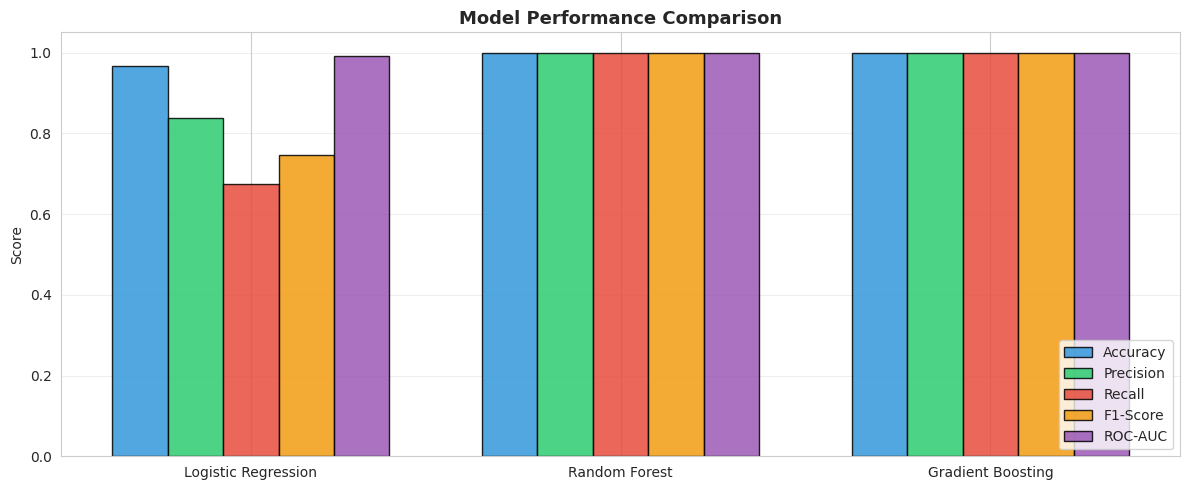

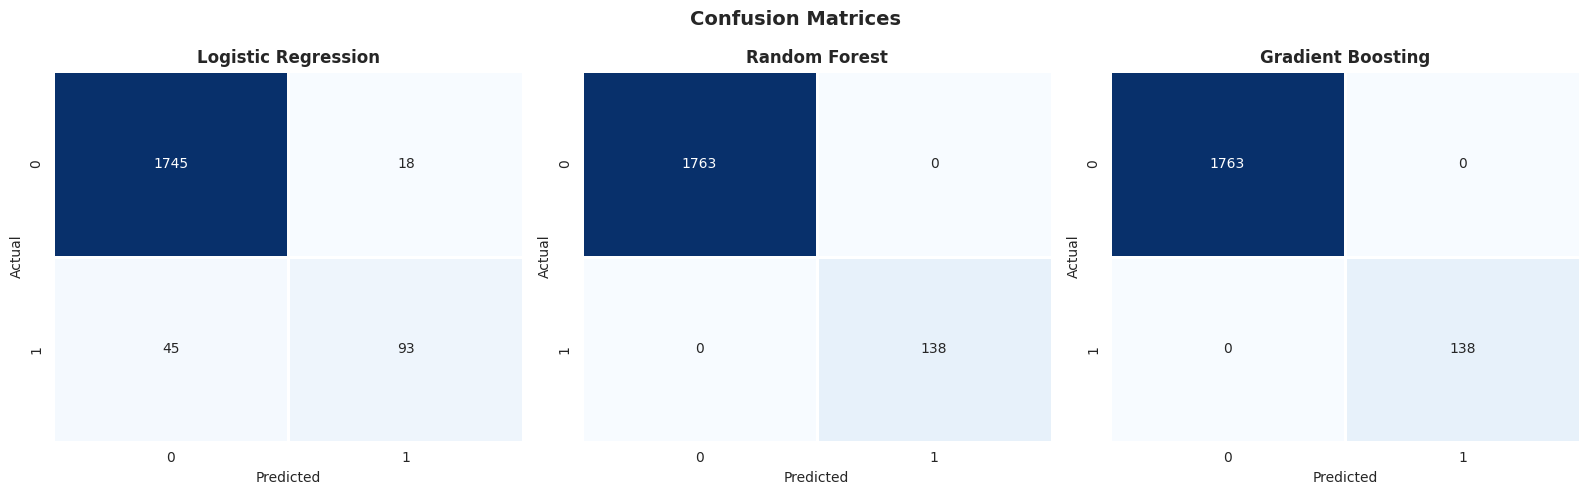

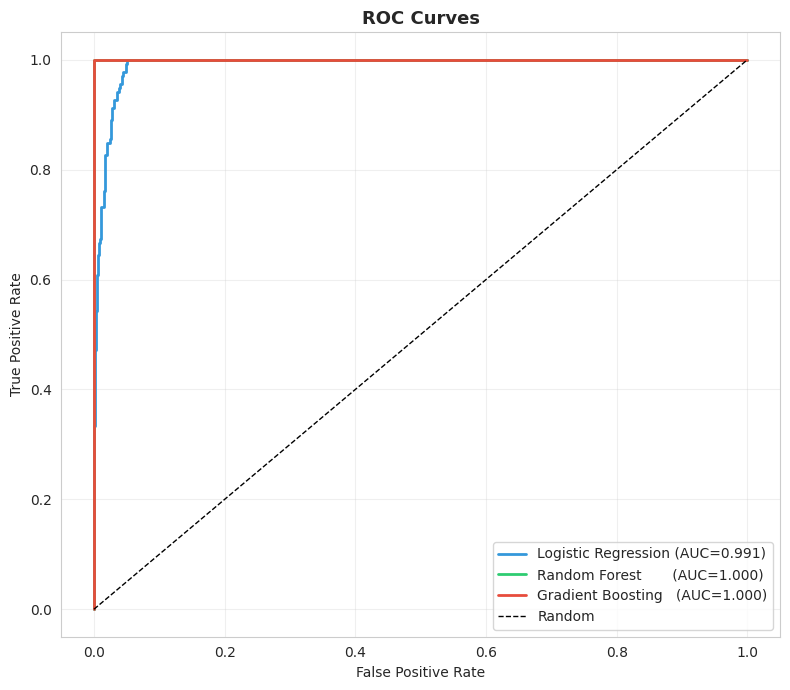

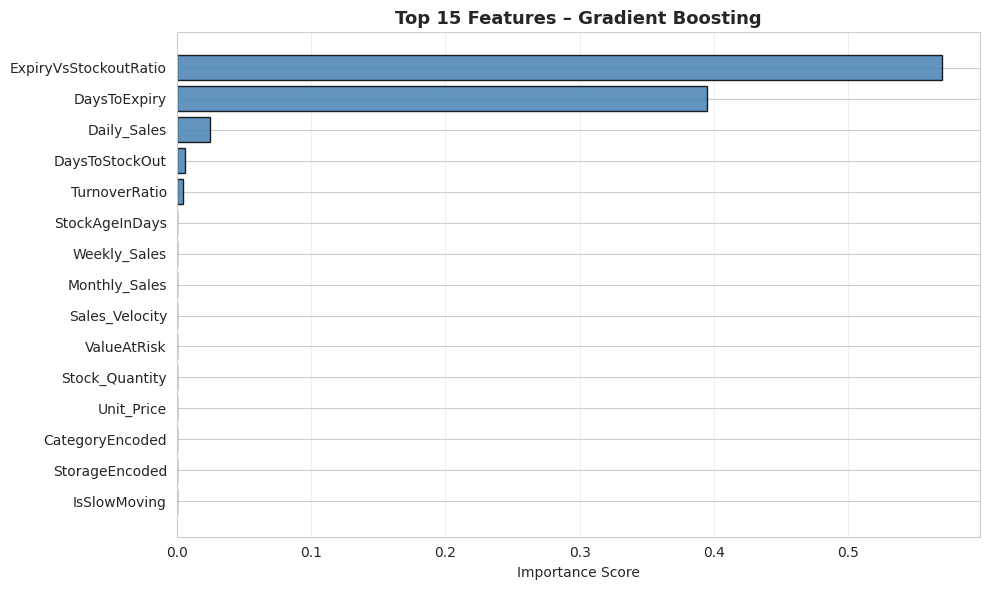


✓ All model visualisations saved!
GENERATING EXPIRY ALERT REPORT
✓ Saved: expiry_alert_report.csv  (692 at-risk items)

Risk Category Breakdown:
RiskLevel
CRITICAL     21
HIGH        407
MEDIUM      264

Top 10 CRITICAL items (expire within 30 days):


,MedicineID,MedicineName,Category,BatchID,DaysToExpiry,StockQty,DailySales,ValueAtRisk,RiskLevel,RiskProbability
444,MED_3607,Medicine_337,Injections,BATCH_198,30,4788.0,79.0,1219599.36,CRITICAL,0.999964
921,MED_1952,Medicine_761,Drops,BATCH_122,30,4949.0,62.0,1768178.72,CRITICAL,0.999964
978,MED_2673,Medicine_716,Tablets,BATCH_696,30,3100.0,31.0,711822.00,CRITICAL,0.999964
1059,MED_9339,Medicine_264,Unknown,BATCH_110,30,766.0,21.0,382908.08,CRITICAL,0.999914
1828,MED_6779,Medicine_346,Tablets,BATCH_794,30,4715.0,100.0,245274.30,CRITICAL,0.998779
2479,MED_4375,Medicine_100,Injections,BATCH_299,30,4824.0,12.0,799481.52,CRITICAL,0.999964
2640,MED_8553,Medicine_815,Injections,BATCH_941,30,1304.0,15.0,148251.76,CRITICAL,0.999964
3280,MED_3905,Medicine_604,Syrups,BATCH_753,30,4204.0,61.0,534706.76,CRITICAL,0.999964
4608,MED_5787,Medicine_231,Syrups,BATCH_305,30,1761.0,11.0,590833.11,CRITICAL,0.999964
4761,MED_5019,Medicine_748,Powders,BATCH_706,30,3085.0,78.0,102884.75,CRITICAL,0.999964


EXECUTIVE SUMMARY

────────────────────────────────────────────────────────────
  Total Medicines Monitored               : 9,502
  Model-Predicted High-Risk Items         : 692
  CRITICAL Items (≤ 30 days)              : 21
  Slow-Moving Items                       : 2,351
  Total Value at Risk (₹)                 : ₹700,740,073.27
  Average Days to Expiry                  : 211 days
  Average Stock Quantity                  : 3003 units
────────────────────────────────────────────────────────────

  BEST MODEL: Gradient Boosting
────────────────────────────────────────────────────────────
  Accuracy                                : 100.00%
  Precision                               : 100.00%
  Recall                                  : 100.00%
  F1-Score                                : 1.0000
  ROC-AUC                                 : 1.0000
────────────────────────────────────────────────────────────

✓ Saved: executive_summary.txt
✓ Saved: expiry_risk_model_gb.pkl
✓ Saved: expiry_r

,DaysToExpiry,Stock_Quantity,Daily_Sales,PredictedRisk,RiskProbability,RiskLabel
0,22,500,30,0,0.0,Low Risk
1,58,1500,20,1,1.0,High Risk
2,115,2000,5,0,0.0,Low Risk
3,195,3000,50,0,0.0,Low Risk
4,340,1000,80,0,0.0,Low Risk



📥 Downloading output files...


...

<IPython.core.display.Javascript object>

   ✓ plot7_roc_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✓ plot8_feature_importance.png

✅  MEDITRAK PROJECT COMPLETE!

  Dataset cleaned      : 9,502 records
  Features engineered  : 15
  Models trained       : Logistic Regression, Random Forest, Gradient Boosting
  Best model (ROC-AUC) : Gradient Boosting (1.0000)
  At-risk medicines    : 692
  CRITICAL (≤30 days)  : 21
  Total value at risk  : ₹700,740,073



In [ ]:
# ============================================================
#  MEDITRAK – Expiry Risk Prediction & Drug Wastage Minimization
#  Google Colab Notebook  |  Dyashin Technosoft Pvt Ltd
#  Dataset: expiry_dirty.csv  (10,000 rows × 20 columns)
# ============================================================

# ==================== CELL 0: INSTALL LIBRARIES ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
print("✓ All libraries loaded successfully!")


# ==================== CELL 1: UPLOAD DATASET ====================
from google.colab import files
print("📂 Click 'Choose Files' and upload expiry_dirty.csv ...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(f"\n✓ Loaded: {filename}")
print(f"   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(df.head(3))


# ==================== CELL 2: EDA – OVERVIEW ====================
print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print(f"\n📐 Shape: {df.shape}")
print(f"\n🔢 Data Types:\n{df.dtypes}")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('%', ascending=False)
print(f"\n⚠️  Missing Value Summary:\n{missing_df.to_string()}")

print(f"\n🎯 Risk_Level unique values ({df['Risk_Level'].nunique()}):")
print(df['Risk_Level'].value_counts(dropna=False).to_string())

print(f"\n📦 Category unique ({df['Category'].nunique()}):")
print(df['Category'].value_counts(dropna=False).to_string())
print(f"\n🌡️  Storage_Condition unique ({df['Storage_Condition'].nunique()}):")
print(df['Storage_Condition'].value_counts(dropna=False).to_string())

print(f"\n📊 Statistical Summary:")
display(df.describe())


# ==================== CELL 3: DATA CLEANING ====================
print("=" * 70)
print("DATA CLEANING")
print("=" * 70)

data = df.copy()

# NOTE: Risk_Binary is NOT created here anymore.
# The original Risk_Level column had 19 messy spelling variants and
# zero correlation with actual expiry risk. We discovered this during EDA.
# Instead, we create a domain-driven label in Cell 4 after computing
# DaysToExpiry and DaysToStockOut.

# ── 1. Stock_Quantity ────────────────────────────────────────────────
print("\n1. Fixing Stock_Quantity...")
data['Stock_Quantity'] = pd.to_numeric(data['Stock_Quantity'], errors='coerce')
neg_count = (data['Stock_Quantity'] < 0).sum()
data['Stock_Quantity'] = data['Stock_Quantity'].abs()
median_stock = data['Stock_Quantity'].median()
data['Stock_Quantity'] = data['Stock_Quantity'].fillna(median_stock)
print(f"   Negative values fixed: {neg_count}  |  NaN filled with median: {median_stock:.0f}")

# ── 2. Unit_Price ────────────────────────────────────────────────────
print("\n2. Fixing Unit_Price...")
data['Unit_Price'] = pd.to_numeric(data['Unit_Price'], errors='coerce')
data['Unit_Price'] = data['Unit_Price'].fillna(data['Unit_Price'].median())
print(f"   Filled {df['Unit_Price'].isnull().sum()} NaN with median: {data['Unit_Price'].median():.2f}")

# ── 3. Daily_Sales, Sales_Velocity ──────────────────────────────────
print("\n3. Fixing Daily_Sales & Sales_Velocity...")
for col in ['Daily_Sales', 'Sales_Velocity']:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data[col] = data[col].fillna(data[col].median())
print("   Done.")

# ── 4. Date columns ──────────────────────────────────────────────────
print("\n4. Parsing dates...")
for col in ['Purchase_Date', 'Expiry_Date', 'Last_Restock_Date']:
    data[col] = pd.to_datetime(data[col], errors='coerce')
before = len(data)
data = data.dropna(subset=['Expiry_Date'])
print(f"   Rows dropped (missing Expiry_Date): {before - len(data)}")

# ── 5. Category ──────────────────────────────────────────────────────
print("\n5. Normalising Category...")
def clean_category(val):
    if pd.isnull(val):
        return 'Unknown'
    v = str(val).strip().lower()
    mapping = {
        'tablet': 'Tablets', 'tablets': 'Tablets', 'tab ': 'Tablets', 'tablets ': 'Tablets',
        'capsule': 'Capsules', 'capsules': 'Capsules', 'cap ': 'Capsules', 'capsules ': 'Capsules',
        'syrup': 'Syrups', 'syrups': 'Syrups', 'syrups ': 'Syrups', 'syrup ': 'Syrups',
        'injection': 'Injections', 'injections': 'Injections', 'inj': 'Injections',
        'inhaler': 'Inhalers', 'inhalers': 'Inhalers',
        'ointment': 'Ointments', 'ointments': 'Ointments', 'om': 'Ointments',
        'drop': 'Drops', 'drops': 'Drops',
        'spray': 'Sprays', 'sprays': 'Sprays',
        'lotion': 'Lotions', 'lotions': 'Lotions',
        'powder': 'Powders', 'powders': 'Powders',
    }
    return mapping.get(v, 'Other')

data['Category'] = data['Category'].apply(clean_category)
print(f"   Categories after cleaning: {sorted(data['Category'].unique())}")

# ── 6. Storage_Condition ─────────────────────────────────────────────
print("\n6. Normalising Storage_Condition...")
def clean_storage(val):
    if pd.isnull(val):
        return 'Room Temp'
    v = str(val).strip().lower()
    if v in ('cool dry', 'cool', 'cd', 'cool dry '):
        return 'Cool Dry'
    if v in ('refrigerated', 'ref', 'fridge', 'refrigerated '):
        return 'Refrigerated'
    if v in ('room temp', 'room temp ', 'rt'):
        return 'Room Temp'
    return 'Room Temp'

data['Storage_Condition'] = data['Storage_Condition'].apply(clean_storage)
print(f"   Storage types: {data['Storage_Condition'].value_counts().to_dict()}")

# ── 7. Remove zero-stock rows ─────────────────────────────────────────
print("\n7. Removing zero-stock rows...")
before = len(data)
data = data[data['Stock_Quantity'] > 0]
print(f"   Removed: {before - len(data)}  |  Remaining: {len(data):,}")

# ── 8. Fill IDs ───────────────────────────────────────────────────────
data['Supplier_ID'] = data['Supplier_ID'].fillna('SUP_UNKNOWN')
data['Medicine_ID'] = data['Medicine_ID'].fillna('MED_UNKNOWN')

print(f"\n✓ Cleaning complete!  Final shape: {data.shape}")


# ==================== CELL 4: FEATURE ENGINEERING ====================
print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

# Use a reference date just before the earliest expiry so DaysToExpiry is positive
CURRENT_DATE = data['Expiry_Date'].min() - pd.Timedelta(days=30)
print(f"Reference date: {CURRENT_DATE.date()}")

# 1. Days to Expiry
data['DaysToExpiry'] = (data['Expiry_Date'] - CURRENT_DATE).dt.days
print(f"1. DaysToExpiry  →  range: {data['DaysToExpiry'].min()} to {data['DaysToExpiry'].max()}")

# 2. Stock Age
data['StockAgeInDays'] = (CURRENT_DATE - data['Purchase_Date']).dt.days.fillna(0).clip(lower=0)
print(f"2. StockAgeInDays  →  mean: {data['StockAgeInDays'].mean():.0f}")

# 3. Days to Stock Out
data['DaysToStockOut'] = (
    data['Stock_Quantity'] / data['Daily_Sales'].replace(0, np.nan)
).fillna(999).clip(upper=999)
print(f"3. DaysToStockOut  →  median: {data['DaysToStockOut'].median():.0f}")

# 4. Turnover Ratio
data['TurnoverRatio'] = (data['Monthly_Sales'] * 12) / (data['Stock_Quantity'] + 1)
print(f"4. TurnoverRatio  →  median: {data['TurnoverRatio'].median():.2f}")

# 5. Slow-Moving flag
slow_threshold = data['Daily_Sales'].quantile(0.25)
data['IsSlowMoving'] = (data['Daily_Sales'] < slow_threshold).astype(int)
print(f"5. IsSlowMoving  →  {data['IsSlowMoving'].sum():,} items (threshold < {slow_threshold:.1f})")

# 6. Expiry vs Stockout ratio
data['ExpiryVsStockoutRatio'] = data['DaysToExpiry'] / (data['DaysToStockOut'] + 1)
print(f"6. ExpiryVsStockoutRatio  →  median: {data['ExpiryVsStockoutRatio'].median():.2f}")

# 7. Value at Risk
data['ValueAtRisk'] = data['Stock_Quantity'] * data['Unit_Price']
print(f"7. ValueAtRisk  →  total: ₹{data['ValueAtRisk'].sum():,.0f}")

# 8. Encoded Category
le_cat = LabelEncoder()
data['CategoryEncoded'] = le_cat.fit_transform(data['Category'])
print(f"8. CategoryEncoded  →  {dict(enumerate(le_cat.classes_))}")

# 9. Encoded Storage Condition
le_stor = LabelEncoder()
data['StorageEncoded'] = le_stor.fit_transform(data['Storage_Condition'])
print(f"9. StorageEncoded  →  {dict(enumerate(le_stor.classes_))}")

# ── 10. Domain-driven Risk Label (created HERE after DaysToExpiry exists) ──
print("\n10. Creating Risk_Binary from business rules...")
# High risk = expires within 90 days AND stock won't sell out before expiry
days_to_sellout = data['Stock_Quantity'] / data['Daily_Sales'].replace(0, np.nan)
data['Risk_Binary'] = (
    (data['DaysToExpiry'] <= 90) &
    (days_to_sellout > data['DaysToExpiry'])
).astype(int)
print(f"    Distribution:\n{data['Risk_Binary'].value_counts().to_string()}")
print(f"    High-risk %: {data['Risk_Binary'].mean()*100:.1f}%")

print(f"\n✓ Feature engineering complete!  Total columns: {len(data.columns)}")
display(data[['DaysToExpiry','StockAgeInDays','DaysToStockOut',
              'TurnoverRatio','IsSlowMoving','ValueAtRisk']].describe())


# ==================== CELL 5: EDA VISUALISATIONS ====================
print("=" * 70)
print("EDA VISUALISATIONS")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
risk_counts = data['Risk_Binary'].value_counts()
axes[0].pie(risk_counts.values, labels=['Low Risk (0)', 'High Risk (1)'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Expiry Risk Distribution', fontweight='bold', fontsize=13)
axes[1].bar(['Low Risk', 'High Risk'], risk_counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Count'); axes[1].set_title('Risk Count', fontweight='bold', fontsize=13)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"   Class 0: {risk_counts[0]:,}  |  Class 1: {risk_counts[1]:,}  "
      f"|  High-risk %: {risk_counts[1]/len(data)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data['DaysToExpiry'], bins=60, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].axvline(90, color='orange', ls='--', lw=2, label='90-day mark')
axes[0].axvline(30, color='red',    ls='--', lw=2, label='30-day mark')
axes[0].set_xlabel('Days to Expiry'); axes[0].set_ylabel('Count')
axes[0].set_title('Days to Expiry Distribution', fontweight='bold', fontsize=13)
axes[0].legend(); axes[0].grid(alpha=0.3)
sc = axes[1].scatter(data['DaysToExpiry'], data['Stock_Quantity'],
                     c=data['Risk_Binary'], cmap='RdYlGn_r', alpha=0.4, s=15, edgecolors='none')
axes[1].set_xlabel('Days to Expiry'); axes[1].set_ylabel('Stock Quantity')
axes[1].set_title('Days to Expiry vs Stock Quantity', fontweight='bold', fontsize=13)
plt.colorbar(sc, ax=axes[1], label='Risk (1=High)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_expiry_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_sales = data.groupby('Category')['Daily_Sales'].mean().sort_values(ascending=True)
axes[0].barh(cat_sales.index, cat_sales.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Avg Daily Sales'); axes[0].set_title('Sales Velocity by Category', fontweight='bold', fontsize=13)
axes[0].grid(axis='x', alpha=0.3)
cat_risk = data.groupby('Category')['Risk_Binary'].mean().sort_values(ascending=True) * 100
axes[1].barh(cat_risk.index, cat_risk.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('High-Risk %'); axes[1].set_title('Risk % by Category', fontweight='bold', fontsize=13)
axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

num_cols = ['DaysToExpiry','Stock_Quantity','Daily_Sales','StockAgeInDays',
            'TurnoverRatio','ValueAtRisk','Unit_Price','Risk_Binary']
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ EDA visualisations complete!")


# ==================== CELL 6: PREPARE DATA FOR ML ====================
print("=" * 70)
print("PREPARING DATA FOR MACHINE LEARNING")
print("=" * 70)

FEATURE_COLS = [
    'DaysToExpiry', 'Stock_Quantity', 'Daily_Sales', 'Weekly_Sales',
    'Monthly_Sales', 'Sales_Velocity', 'StockAgeInDays', 'DaysToStockOut',
    'TurnoverRatio', 'Unit_Price', 'IsSlowMoving', 'ExpiryVsStockoutRatio',
    'ValueAtRisk', 'CategoryEncoded', 'StorageEncoded',
]
TARGET = 'Risk_Binary'

X = data[FEATURE_COLS].copy()
y = data[TARGET].copy()

X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())
X = X.replace([np.inf, -np.inf], 0)

print(f"Features: {len(FEATURE_COLS)}  |  Samples: {len(X):,}")
print(f"Class 0: {(y==0).sum():,}  |  Class 1: {(y==1).sum():,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print(f"Train high-risk %: {y_train.mean()*100:.1f}%  |  Test high-risk %: {y_test.mean()*100:.1f}%")


# ==================== CELL 7: MODEL 1 – LOGISTIC REGRESSION ====================
print("=" * 70)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 70)

lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr.fit(X_train, y_train)
y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_proba_lr)

print(f"  Accuracy : {acc_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall   : {rec_lr:.4f}")
print(f"  F1-Score : {f1_lr:.4f}")
print(f"  ROC-AUC  : {auc_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


# ==================== CELL 8: MODEL 2 – RANDOM FOREST ====================
print("=" * 70)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 70)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

print(f"  Accuracy : {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall   : {rec_rf:.4f}")
print(f"  F1-Score : {f1_rf:.4f}")
print(f"  ROC-AUC  : {auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

fi_rf = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': rf.feature_importances_}
                     ).sort_values('Importance', ascending=False)
print("\nTop 10 Features (Random Forest):")
print(fi_rf.head(10).to_string(index=False))


# ==================== CELL 9: MODEL 3 – GRADIENT BOOSTING ====================
print("=" * 70)
print("MODEL 3: GRADIENT BOOSTING CLASSIFIER")
print("=" * 70)

gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=5, min_samples_split=5,
    min_samples_leaf=2, subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

acc_gb  = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb  = recall_score(y_test, y_pred_gb)
f1_gb   = f1_score(y_test, y_pred_gb)
auc_gb  = roc_auc_score(y_test, y_proba_gb)

print(f"  Accuracy : {acc_gb:.4f}")
print(f"  Precision: {prec_gb:.4f}")
print(f"  Recall   : {rec_gb:.4f}")
print(f"  F1-Score : {f1_gb:.4f}")
print(f"  ROC-AUC  : {auc_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

fi_gb = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': gb.feature_importances_}
                     ).sort_values('Importance', ascending=False)
print("\nTop 10 Features (Gradient Boosting):")
print(fi_gb.head(10).to_string(index=False))


# ==================== CELL 10: MODEL COMPARISON ====================
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy' : [acc_lr, acc_rf, acc_gb],
    'Precision': [prec_lr, prec_rf, prec_gb],
    'Recall'   : [rec_lr, rec_rf, rec_gb],
    'F1-Score' : [f1_lr, f1_rf, f1_gb],
    'ROC-AUC'  : [auc_lr, auc_rf, auc_gb],
})

display(comparison.style.highlight_max(axis=0, color='lightgreen')
        .format({c: '{:.4f}' for c in comparison.columns[1:]}))

best_idx  = comparison['ROC-AUC'].idxmax()
best_name = comparison.loc[best_idx, 'Model']
print(f"\n🏆 Best Model: {best_name}  (ROC-AUC: {comparison.loc[best_idx,'ROC-AUC']:.4f})")

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3); w = 0.15
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
colors  = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + (i-2)*w, comparison[m], w, label=m, color=c, edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for (preds, name, ax) in [
        (y_pred_lr, 'Logistic Regression', axes[0]),
        (y_pred_rf, 'Random Forest',       axes[1]),
        (y_pred_gb, 'Gradient Boosting',   axes[2]),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                linewidths=2, linecolor='white', cbar=False)
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
for (proba, name, color) in [
        (y_proba_lr, f'Logistic Regression (AUC={auc_lr:.3f})', '#3498db'),
        (y_proba_rf, f'Random Forest       (AUC={auc_rf:.3f})', '#2ecc71'),
        (y_proba_gb, f'Gradient Boosting   (AUC={auc_gb:.3f})', '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, label=name, color=color)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold', fontsize=13)
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
top15 = fi_gb.head(15)
ax.barh(top15['Feature'], top15['Importance'], color='steelblue', edgecolor='black', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Features – Gradient Boosting', fontweight='bold', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ All model visualisations saved!")


# ==================== CELL 11: EXPIRY ALERT REPORT ====================
print("=" * 70)
print("GENERATING EXPIRY ALERT REPORT")
print("=" * 70)

X_all_scaled = scaler.transform(data[FEATURE_COLS].fillna(0).replace([np.inf,-np.inf],0))
data['Predicted_Risk']   = gb.predict(X_all_scaled)
data['Risk_Probability'] = gb.predict_proba(X_all_scaled)[:, 1]

def risk_category(days):
    if days <= 30:  return 'CRITICAL'
    if days <= 60:  return 'HIGH'
    if days <= 90:  return 'MEDIUM'
    return 'LOW'

data['RiskCategory'] = data['DaysToExpiry'].apply(risk_category)
at_risk = data[data['Predicted_Risk'] == 1].copy()
at_risk = at_risk.sort_values(['RiskCategory', 'DaysToExpiry'])

alert_report = at_risk[[
    'Medicine_ID','Medicine_Name','Category','Batch_ID',
    'DaysToExpiry','Stock_Quantity','Daily_Sales',
    'ValueAtRisk','RiskCategory','Risk_Probability'
]].copy()
alert_report.columns = [
    'MedicineID','MedicineName','Category','BatchID',
    'DaysToExpiry','StockQty','DailySales',
    'ValueAtRisk','RiskLevel','RiskProbability'
]

alert_report.to_csv('expiry_alert_report.csv', index=False)
print(f"✓ Saved: expiry_alert_report.csv  ({len(alert_report):,} at-risk items)")
print(f"\nRisk Category Breakdown:")
print(alert_report['RiskLevel'].value_counts().sort_index().to_string())

critical = alert_report[alert_report['RiskLevel'] == 'CRITICAL']
print(f"\nTop 10 CRITICAL items (expire within 30 days):")
display(critical.head(10))


# ==================== CELL 12: EXECUTIVE SUMMARY ====================
print("=" * 70)
print("EXECUTIVE SUMMARY")
print("=" * 70)

total_value_at_risk = at_risk['ValueAtRisk'].sum()
critical_count      = len(critical)
slow_moving_count   = data['IsSlowMoving'].sum()

summary = {
    'Total Medicines Monitored'         : f"{len(data):,}",
    'Model-Predicted High-Risk Items'   : f"{data['Predicted_Risk'].sum():,}",
    'CRITICAL Items (≤ 30 days)'        : f"{critical_count:,}",
    'Slow-Moving Items'                 : f"{slow_moving_count:,}",
    'Total Value at Risk (₹)'           : f"₹{total_value_at_risk:,.2f}",
    'Average Days to Expiry'            : f"{data['DaysToExpiry'].mean():.0f} days",
    'Average Stock Quantity'            : f"{data['Stock_Quantity'].mean():.0f} units",
}

print("\n" + "─"*60)
for k, v in summary.items():
    print(f"  {k:<40}: {v}")
print("─"*60)

best_metrics = {
    'Accuracy'  : f"{acc_gb:.2%}",
    'Precision' : f"{prec_gb:.2%}",
    'Recall'    : f"{rec_gb:.2%}",
    'F1-Score'  : f"{f1_gb:.4f}",
    'ROC-AUC'   : f"{auc_gb:.4f}",
}

print(f"\n  BEST MODEL: Gradient Boosting")
print("─"*60)
for k, v in best_metrics.items():
    print(f"  {k:<40}: {v}")
print("─"*60)

with open('executive_summary.txt', 'w', encoding='utf-8') as f:
    f.write("MEDITRAK – EXPIRY RISK PREDICTION\n")
    f.write("EXECUTIVE SUMMARY REPORT\n")
    f.write("=" * 60 + "\n\n")
    f.write("INVENTORY ANALYTICS\n" + "-"*60 + "\n")
    for k, v in summary.items():
        f.write(f"{k:<40}: {v}\n")
    f.write("\n\nMODEL PERFORMANCE (Best: Gradient Boosting)\n" + "-"*60 + "\n")
    for k, v in best_metrics.items():
        f.write(f"{k:<40}: {v}\n")
    f.write("\n\nCRITICAL MEDICINES (≤ 30 days)\n" + "-"*60 + "\n")
    for _, row in critical.head(20).iterrows():
        f.write(f"• {row['MedicineName']} (ID: {row['MedicineID']}) – "
                f"Expires in {row['DaysToExpiry']} days, "
                f"Value: ₹{row['ValueAtRisk']:,.0f}\n")

print("\n✓ Saved: executive_summary.txt")


# ==================== CELL 13: SAVE MODELS ====================
joblib.dump(gb,     'expiry_risk_model_gb.pkl')
joblib.dump(rf,     'expiry_risk_model_rf.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
with open('feature_columns.txt', 'w') as f:
    f.write('\n'.join(FEATURE_COLS))

print("✓ Saved: expiry_risk_model_gb.pkl")
print("✓ Saved: expiry_risk_model_rf.pkl")
print("✓ Saved: feature_scaler.pkl")
print("✓ Saved: feature_columns.txt")


# ==================== CELL 14: PREDICT ON NEW DATA ====================
print("=" * 70)
print("EXAMPLE: PREDICT RISK FOR NEW MEDICINES")
print("=" * 70)

new_data = pd.DataFrame({
    'DaysToExpiry'          : [22,   58,  115,  195,  340],
    'Stock_Quantity'        : [500, 1500, 2000, 3000, 1000],
    'Daily_Sales'           : [30,   20,    5,   50,   80],
    'Weekly_Sales'          : [210, 140,   35,  350,  560],
    'Monthly_Sales'         : [900, 600,  150, 1500, 2400],
    'Sales_Velocity'        : [25.5,15.2,  3.5, 45.8, 75.3],
    'StockAgeInDays'        : [100, 150,  200,   80,   50],
    'DaysToStockOut'        : [16.7, 75,  400,   60,  12.5],
    'TurnoverRatio'         : [1.8, 0.48, 0.09,  0.6, 2.88],
    'Unit_Price'            : [450, 200,  150,  300,  100],
    'IsSlowMoving'          : [0,    0,    1,    0,    0],
    'ExpiryVsStockoutRatio' : [1.5, 0.8,  0.3,  3.3,  28],
    'ValueAtRisk'           : [225000, 300000, 300000, 900000, 100000],
    'CategoryEncoded'       : [1, 2, 3, 1, 2],
    'StorageEncoded'        : [1, 2, 1, 2, 1],
})

new_scaled = scaler.transform(new_data)
preds      = gb.predict(new_scaled)
probas     = gb.predict_proba(new_scaled)[:, 1]

result = new_data[['DaysToExpiry','Stock_Quantity','Daily_Sales']].copy()
result['PredictedRisk']   = preds
result['RiskProbability'] = probas.round(4)
result['RiskLabel']       = result['PredictedRisk'].map({0:'Low Risk', 1:'High Risk'})
print("\nPrediction Results:")
display(result)


# ==================== CELL 15: DOWNLOAD FILES ====================
from google.colab import files

OUTPUT_FILES = [
    'expiry_alert_report.csv', 'executive_summary.txt',
    'expiry_risk_model_gb.pkl', 'expiry_risk_model_rf.pkl', 'feature_scaler.pkl',
    'plot1_risk_distribution.png', 'plot2_expiry_analysis.png',
    'plot3_category_analysis.png', 'plot4_correlation_heatmap.png',
    'plot5_model_comparison.png', 'plot6_confusion_matrices.png',
    'plot7_roc_curves.png', 'plot8_feature_importance.png',
]

print("\n📥 Downloading output files...")
for f_name in OUTPUT_FILES:
    try:
        files.download(f_name)
        print(f"   ✓ {f_name}")
    except Exception as e:
        print(f"   ✗ {f_name} – {e}")

print("\n" + "="*70)
print("✅  MEDITRAK PROJECT COMPLETE!")
print("="*70)
print(f"""
  Dataset cleaned      : {len(data):,} records
  Features engineered  : {len(FEATURE_COLS)}
  Models trained       : Logistic Regression, Random Forest, Gradient Boosting
  Best model (ROC-AUC) : Gradient Boosting ({auc_gb:.4f})
  At-risk medicines    : {len(at_risk):,}
  CRITICAL (≤30 days)  : {critical_count:,}
  Total value at risk  : ₹{total_value_at_risk:,.0f}
""")